# 🤖 Supervised Learning — Complete Revision Notebook
### Module 4 | Day 1

Supervised Learning is the branch of Machine Learning where a model learns from **labeled data** —
every training example comes with the correct answer (the "label" or "target"). The model's job is to
learn the mapping from inputs (features) to outputs (labels), so it can predict the label for new,
unseen inputs.

This notebook covers:

1. What is Supervised Learning?
2. Regression vs Classification
3. The Supervised Learning Workflow
4. Regression — Linear Regression (predicting a number)
5. Classification — Logistic Regression, KNN, Decision Tree, Random Forest (predicting a category)
6. Model Evaluation Metrics
7. Bias-Variance Tradeoff & Overfitting/Underfitting
8. Cross-Validation
9. Model Comparison
10. Key Takeaways


## 🐍 0. Setup — Libraries

We'll use **Scikit-learn** for models, metrics, and datasets, plus **NumPy / Pandas** for data handling
and **Matplotlib / Seaborn** for visualization.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(42)

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 1. What is Supervised Learning?

In Supervised Learning, every training example is a pair: **(input features, correct output)**.
The model learns a function that maps features → output by minimizing the error between its
predictions and the true labels.

| | |
|---|---|
| **Input** | Features (X) — e.g. study hours, attendance, age, pixel values |
| **Output** | Label / Target (y) — the correct answer we want to predict |
| **Goal** | Learn `f(X) ≈ y` so it generalizes to new, unseen data |

### Two Main Types of Supervised Learning

| Type | Predicts | Example |
|---|---|---|
| **Regression** | A continuous number | House price, exam score, temperature |
| **Classification** | A category / class | Spam or not spam, disease or healthy, digit 0–9 |


## 2. The Supervised Learning Workflow

```
Labeled Data
   -> Train / Test Split
   -> Choose a Model
   -> Train (fit) the Model on the Training Set
   -> Predict on the Test Set
   -> Evaluate with Metrics
   -> Tune / Improve the Model
```

This is the same pipeline regardless of whether we're solving a regression or classification problem —
only the model and the evaluation metrics change.


---
## 3. Regression — Predicting a Continuous Number

We'll create a synthetic dataset representing **"Study Hours → Exam Score"** and fit a
**Linear Regression** model, one of the simplest and most interpretable supervised learning algorithms.

Linear Regression assumes a linear relationship: `score = w × study_hours + b`, and learns the best
weight `w` and bias `b` by minimizing the **Mean Squared Error** between predictions and actual scores.


In [2]:
# Create a synthetic regression dataset: study_hours -> exam_score
X_reg, y_reg = make_regression(
    n_samples=150, n_features=1, noise=12, random_state=42
)
X_reg = (X_reg - X_reg.min()) / (X_reg.max() - X_reg.min()) * 10  # scale to 0-10 study hours
y_reg = y_reg / 10 + 70  # scale to realistic exam scores

reg_df = pd.DataFrame({"study_hours": X_reg.flatten(), "score": y_reg})
reg_df.head()


   study_hours      score
0     3.073063  61.505599
1     5.372171  71.096498
2     1.991470  54.984593
3     5.791533  71.724095
4     4.509323  66.711937

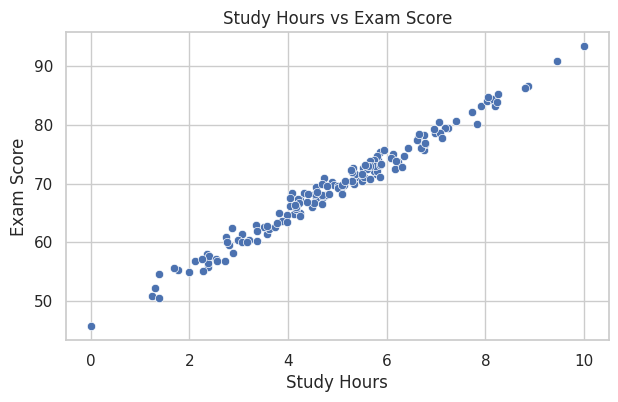

In [3]:
# Visualize the raw relationship
plt.figure()
sns.scatterplot(data=reg_df, x="study_hours", y="score")
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()


In [4]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    reg_df[["study_hours"]], reg_df["score"], test_size=0.2, random_state=42
)

# Train a Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print(f"Learned weight (slope): {lin_reg.coef_[0]:.2f}")
print(f"Learned bias (intercept): {lin_reg.intercept_:.2f}")


Learned weight (slope): 4.61
Learned bias (intercept): 46.42


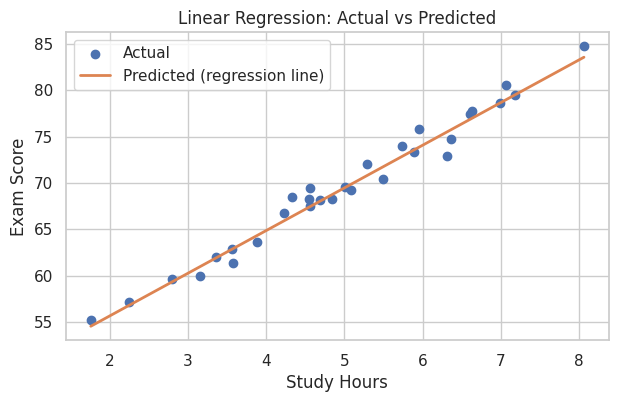

In [5]:
# Predict on the test set
y_pred_reg = lin_reg.predict(X_test)

# Visualize predictions vs actual
plt.figure()
plt.scatter(X_test, y_test, label="Actual", color="#4C72B0")
plt.plot(X_test.sort_values("study_hours"),
         lin_reg.predict(X_test.sort_values("study_hours")),
         color="#DD8452", linewidth=2, label="Predicted (regression line)")
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.legend()
plt.show()


### 3.1 Regression Evaluation Metrics

| Metric | What it measures |
|---|---|
| **MAE** (Mean Absolute Error) | Average absolute difference between predicted and actual values |
| **MSE** (Mean Squared Error) | Average squared difference — penalizes larger errors more |
| **RMSE** (Root MSE) | Same units as the target, easier to interpret than MSE |
| **R² Score** | Proportion of variance in the target explained by the model (closer to 1 is better) |


In [6]:
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")


MAE:  0.85
MSE:  1.22
RMSE: 1.11
R2:   0.98


---
## 4. Classification — Predicting a Category

We'll create a synthetic **binary classification** dataset (e.g. "Pass" vs "Fail" based on study
habits) and compare several classic classification algorithms:

- **Logistic Regression** — a linear model that predicts class probabilities
- **K-Nearest Neighbors (KNN)** — classifies a point based on its closest neighbors
- **Decision Tree** — splits data using a series of if/else rules
- **Random Forest** — an ensemble of many decision trees (usually more accurate and robust)


In [7]:
# Create a synthetic classification dataset
X_clf, y_clf = make_classification(
    n_samples=300, n_features=4, n_informative=3, n_redundant=1,
    n_classes=2, weights=[0.55, 0.45], random_state=42
)

clf_df = pd.DataFrame(X_clf, columns=["study_hours", "attendance", "sleep_hours", "prior_score"])
clf_df["passed"] = y_clf

clf_df.head()


   study_hours  attendance  sleep_hours  prior_score  passed
0    -1.006533   -1.165914    -1.188092    -1.583266       0
1    -0.166394   -2.784863    -2.020881    -1.414560       0
2     0.456754   -0.803565     0.016018     1.257457       1
3     0.533257   -0.467979     0.147174     1.124895       0
4     0.536633    0.101706     0.287001     0.666098       1

passed
0    0.546667
1    0.453333
Name: proportion, dtype: float64


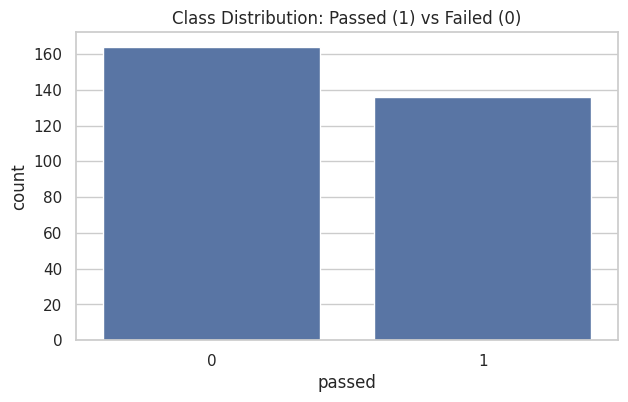

In [8]:
# Class balance check
print(clf_df["passed"].value_counts(normalize=True).rename("proportion"))

plt.figure()
sns.countplot(data=clf_df, x="passed")
plt.title("Class Distribution: Passed (1) vs Failed (0)")
plt.show()


In [9]:
# Train/Test split + feature scaling (important for KNN & Logistic Regression)
X = clf_df.drop(columns=["passed"])
y = clf_df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape, " Test set:", X_test.shape)


Training set: (225, 4)  Test set: (75, 4)


In [10]:
# Train multiple classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     0.813      0.778   0.824     0.800
K-Nearest Neighbors     0.880      0.931   0.794     0.857
Decision Tree           0.787      0.737   0.824     0.778
Random Forest           0.867      0.900   0.794     0.844

### 4.1 Classification Evaluation Metrics

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall proportion of correct predictions |
| **Precision** | Of all predicted positives, how many were actually positive? (avoids false alarms) |
| **Recall** | Of all actual positives, how many did we correctly catch? (avoids missed cases) |
| **F1 Score** | Harmonic mean of Precision and Recall — a balanced single score |

> Accuracy alone can be misleading on imbalanced datasets — always check Precision/Recall/F1 too.


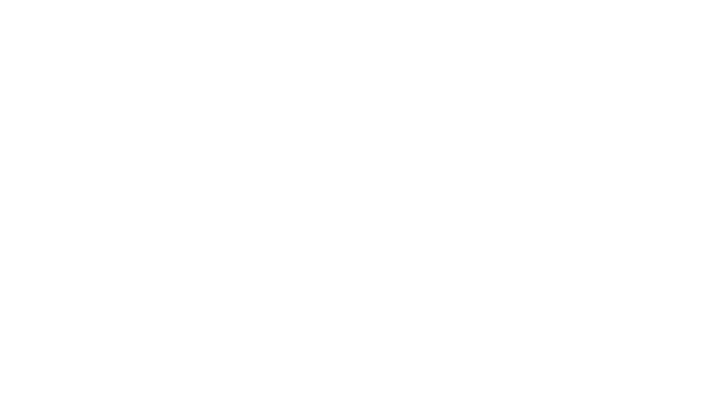

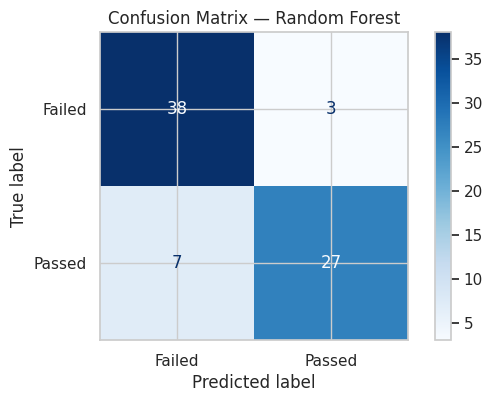

In [11]:
# Confusion Matrix for the best model (Random Forest)
best_model = models["Random Forest"]
preds_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Failed", "Passed"])

plt.figure()
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random Forest")
plt.show()


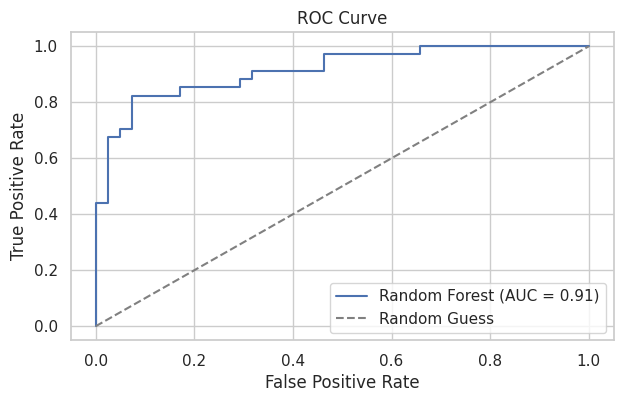

In [12]:
# ROC Curve & AUC — how well the model separates the two classes
probs = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})", color="#4C72B0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


---
## 5. Bias-Variance Tradeoff & Overfitting vs Underfitting

| Concept | Description | Symptom |
|---|---|---|
| **Underfitting (High Bias)** | Model is too simple to capture patterns | Poor performance on both train & test data |
| **Overfitting (High Variance)** | Model memorizes training data, including noise | Great on train data, poor on test data |
| **Good Fit** | Model captures the true underlying pattern | Consistent performance on train & test data |

We can see this directly by comparing a shallow Decision Tree (underfitting risk) vs a very deep one
(overfitting risk) on the same data.


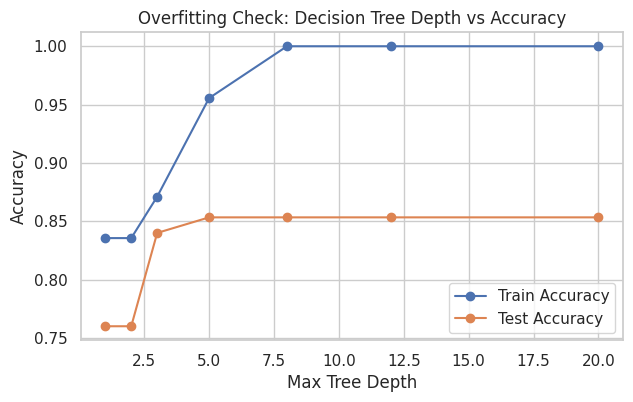

In [13]:
depths = [1, 2, 3, 5, 8, 12, 20]
train_scores, test_scores = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, tree.predict(X_test_scaled)))

plt.figure()
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.title("Overfitting Check: Decision Tree Depth vs Accuracy")
plt.xlabel("Max Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Notice how training accuracy keeps climbing as the tree gets deeper, while test accuracy plateaus
or drops — a classic sign of **overfitting**. The best depth is where test accuracy is highest, not
where train accuracy is highest.


## 6. Cross-Validation

A single train/test split can be lucky or unlucky. **K-Fold Cross-Validation** splits the data into
*K* folds, trains on *K-1* folds and validates on the remaining one, repeating *K* times — giving a
more reliable estimate of how the model performs on unseen data.


In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    X, y, cv=kfold, scoring="accuracy"
)

print("Accuracy per fold:", np.round(cv_scores, 3))
print(f"Mean CV Accuracy: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")


Accuracy per fold: [0.867 0.833 0.917 0.767 0.9  ]
Mean CV Accuracy: 0.857  (+/- 0.053)


## 7. Model Comparison — Visual Summary


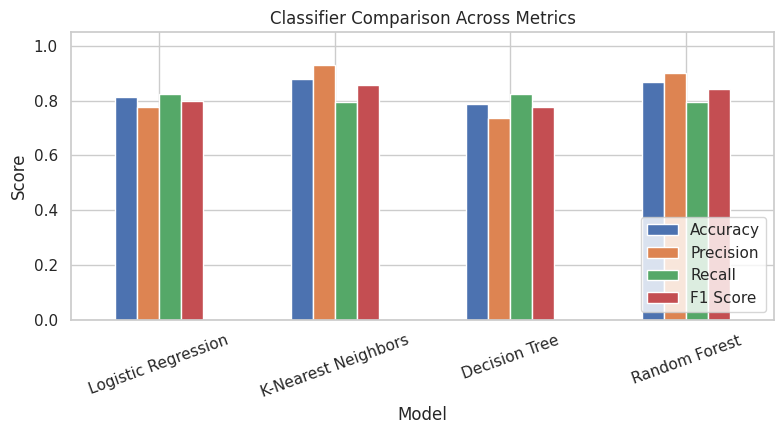

In [15]:
plt.figure(figsize=(8, 4.5))
results_df.plot(kind="bar", ax=plt.gca())
plt.title("Classifier Comparison Across Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


---
## 🔑 Key Takeaways

- **Supervised Learning** learns from labeled data: features (X) mapped to known outputs (y).
- **Regression** predicts continuous numbers (e.g. price, score); **Classification** predicts categories (e.g. pass/fail, spam/not spam).
- Common regression metrics: **MAE, MSE, RMSE, R²**.
- Common classification metrics: **Accuracy, Precision, Recall, F1**, plus the **Confusion Matrix** and **ROC/AUC**.
- **Overfitting** = great on training data, poor on new data. **Underfitting** = poor on both.
- **Cross-Validation** gives a more trustworthy performance estimate than a single train/test split.
- Simple models (Linear/Logistic Regression) are interpretable; ensemble models (Random Forest) are usually more accurate but less transparent.

**Next up (Module 4, Day 2):** Unsupervised Learning — Clustering, Dimensionality Reduction, and finding structure in unlabeled data.
